# MobGap Tutorial

The data we captured today is stored in a ".cwa" file. This is a compressed, space efficient format where values are represented in bytes that must be transformed into readable values. Luckily, we've built some functions to do this.

First, let's get a list of all the ".cwa" files in the current folder. Make sure your file is in the same folder as this script and run the code below.

In [1]:
import os
def get_paths_with_extension(extension):
    paths = []
    dataset_folder = os.path.join(os.getcwd())

    for root, dirs, files in os.walk(dataset_folder):
        for file in files:
            if file.lower().endswith(extension):
                path = os.path.join(root, file)
                if not ".venv" in path:
                    paths.append(path)
    
    return paths

cwa_files = get_paths_with_extension(".cwa")

print("Here is the list of all our \".cwa\" files:")
print(cwa_files)

Here is the list of all our ".cwa" files:
['C:\\Users\\ac4jmi\\PycharmProjects\\mobilise-d_mobgap_tutorial\\6033814_0000000000.cwa']


Now let's run the following cell, which imports some functions from our "functions.py" file and uses them to read the data from the ".cwa" file.

Then, we'll plot this data to see what we're working with.

In [2]:
from functions import *
import pandas as pd

if len(cwa_files) > 1:
    print("Error, more than 1 \".cwa\" file in your folder, make sure you just have your file from today in there!")
else:
    samples = get_cwa_data(cwa_files[0], resample = True, prints = 0)

# note that we use display to make things look nice in notebooks, rather than print.
# If you want to see why, try replacing the following "display" with "print"...
display(samples.head(10))

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,2026-07-02 13:20:27.292779008,0.084717,-0.049316,1.021484,-40.771484,-11.596680,-33.874512
1,2026-07-02 13:20:27.302778880,0.097656,-0.062744,0.985840,-44.799805,-6.286621,-34.057617
2,2026-07-02 13:20:27.312779008,0.077393,-0.089111,0.939941,-47.180176,-2.502441,-35.461426
3,2026-07-02 13:20:27.322778880,0.106201,-0.083496,0.926514,-45.288086,0.854492,-39.978027
4,2026-07-02 13:20:27.332779008,0.090576,-0.085693,0.942871,-45.898438,-0.732422,-42.236328
5,2026-07-02 13:20:27.342778880,0.075684,-0.119141,0.950684,-49.499512,-2.563477,-45.349121
6,2026-07-02 13:20:27.352779008,0.074951,-0.126465,0.966309,-51.086426,-6.530762,-46.569824
7,2026-07-02 13:20:27.362778880,0.083008,-0.138672,0.989502,-53.344727,-14.221191,-45.471191
8,2026-07-02 13:20:27.372779008,0.084229,-0.137939,1.019775,-61.706543,-21.362305,-41.442871
9,2026-07-02 13:20:27.382778880,0.091064,-0.141846,1.030518,-66.711426,-23.437500,-35.949707


Great! Now let's plot the data to see what this actually looks like. If you want, you can also see what the other axes look like by swapping out "accel_x" for:
- accel_y
- accel_z
- gyro_x
- gyro_y
- gyro_z

As seen in the table above. You can even plot the "timestamp" if you like but it'll just be a straight line.

<Axes: >

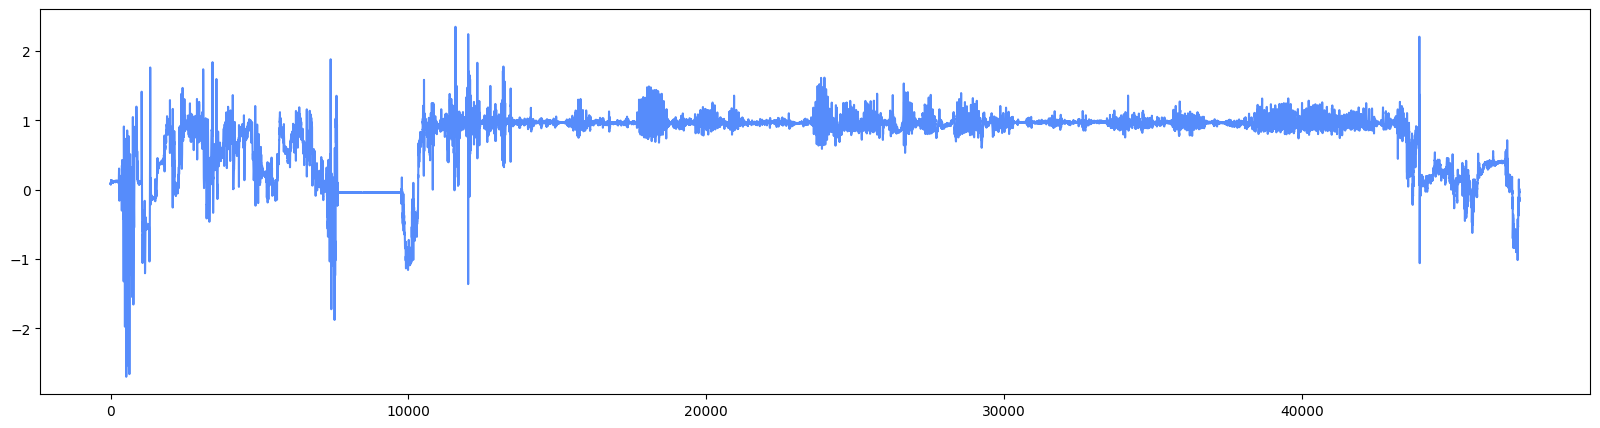

In [3]:
samples["accel_x"].plot(figsize = (20, 5)) # note that figsize contains the x and y sizes for the figure. Have a play with these to see what happens.

We can be a bit smarter with our plots. If we use matplotlib, we can select a specific region of the data to plot. In the cell below, enter a start and end index (start_id and end_id) that you'd like to see and run the cell to see "accel_x" plotted against timestamp so that we can see exactly when this data was recorded. Again we can change "accel_x" to any of the columns to see them plotted over time.

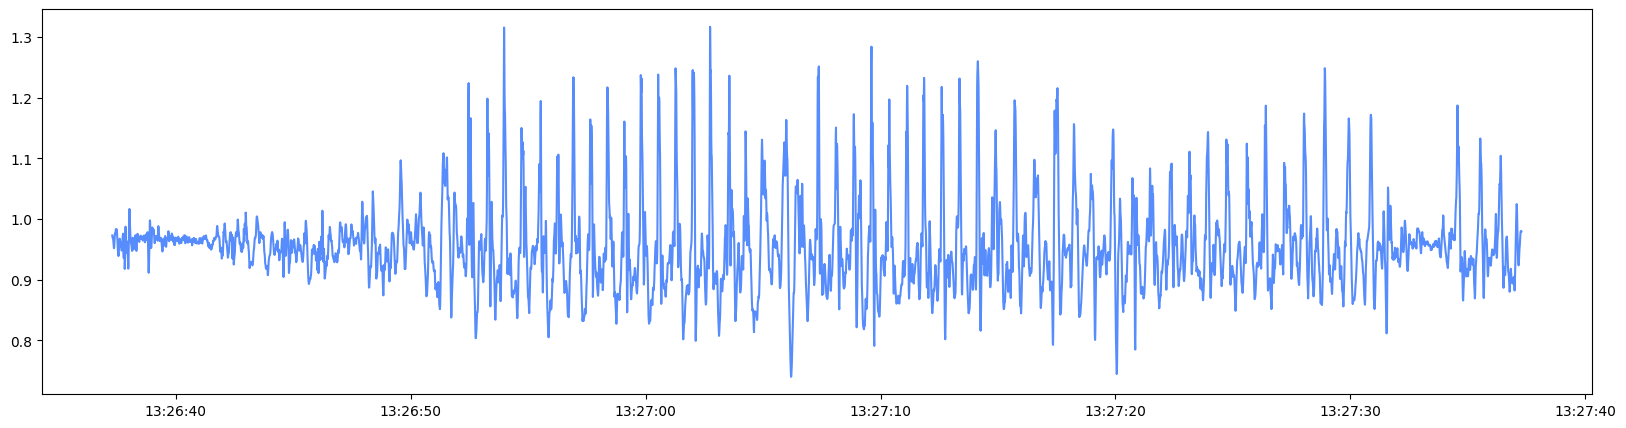

In [4]:
import matplotlib.pyplot as plt    # we'll use matplotlib for this plot

start_id = 37000    # the first point we want to plot - feel free to change
end_id = 43000   # the last point we want to plot - feel free to change

samples_to_plot = samples.iloc[start_id:end_id] # here we make a copy of our table, but use iloc to get just the values from the start_id to the end_id

plt.figure(figsize=(20, 5))                                   # first, we tell matplotlib how big the figure will be.
plt.plot(samples_to_plot["timestamp"], samples_to_plot["accel_x"]) # next, we plot the x and y axes as columns from our table
plt.show()                                                    # finally, we show the figure

Now, don't worry too much about these following cells. Basically, we currently have our time in <b>human-readable time</b>, but MobGap needs the time in <b>unix time</b>.

Unix time is the number of seconds since the <b>unix epoch</b> which was 1-1-1970.

Run the cell below and see what this looks like. It should be an array of times starting at about 1.8 billion seconds.

In [5]:
reformatted_time = samples["timestamp"].astype('int64') // 10**9  # convert nanoseconds to seconds
reformatted_time = reformatted_time.values.reshape(-1, 1).astype(float)

display(reformatted_time)

array([[1.78299843e+09],
       [1.78299843e+09],
       [1.78299843e+09],
       ...,
       [1.78299890e+09],
       [1.78299890e+09],
       [1.78299890e+09]], shape=(47321, 1))

Now we'll look at the start time by getting the first item in the timestamp column from our data, and formatting it as <b>day-mon-year hh:mm:ss</b>.

You should see today's date, and the time that we started recording.

In [6]:
start_date_time = samples["timestamp"].iloc[0].strftime('%d-%b-%Y %H:%M:%S')
print(start_date_time)

02-Jul-2026 13:20:27


Next we'll set our sample rate.

These sensors record 100 samples per second - 100 Hz.

In [7]:
fs = 100
#fs = len(samples)/(reformatted_time[-1][0] - reformatted_time[0][0])
print(fs)

100


In [8]:
data = {
    "TimeMeasure1": {
        "Test1": {
            "Trial1": {
                "SU": {
                    "LowerBack": {
                        "Fs": {
                            "Acc": fs,
                            "Gyr": fs
                        },
                        "Acc": samples[["accel_x", "accel_y", "accel_z"]].values.astype(float),
                        "Gyr": samples[["gyro_x", "gyro_y", "gyro_z"]].values.astype(float),
                        "Timestamp": reformatted_time
                    }
                }, 
                "StartDateTime": start_date_time,
                "TimeZone": "Europe/UK"
            }
        }
    }
}

data = {"data": data}

In [9]:
gender = "M"
handedness = "R"
age = 26
weight = 80.4
height = 183
sensor_height = 111

infoForAlgo = {
    "TimeMeasure1": {
        "Subject_ID": "1",
        "Cohort": "HA",
        "Gender": gender,
        "Handedness": handedness,
        "Age": age,
        "Weight": weight,
        "Height": height,
        "SensorHeight": sensor_height,
        "WalkingAid_01": 0,
        "WalkingAid_Side": "",
        "WalkingAid_Description": "",
        "SensorType_SU": "AX6",
        "SensorAttachment_SU": "Body-Worn"
    }
}

infoForAlgo = {"infoForAlgo": infoForAlgo}

In [10]:
current_dir = os.getcwd()                                   # get current working directory (cwd)
target_dir = os.path.join(current_dir, r'Dataset/HA/1')     # define the target directory relative to the current directory
if not os.path.exists(target_dir):                          # check if the folders already exist
   os.makedirs(target_dir)                                  # if they dont, make the folders

In [11]:
from scipy.io import savemat

savemat(target_dir + "\\infoForAlgo.mat", infoForAlgo, do_compression=False)
savemat(target_dir + "\\data.mat", data, do_compression=False)

In [12]:
from mobgap.data import GenericMobilisedDataset

mat_files = get_paths_with_extension(".mat")
mat_files = [file for file in mat_files if file.endswith("data.mat")]
print(mat_files)
dataset = GenericMobilisedDataset(
    paths_list = mat_files,
    test_level_names = ["TimeMeasure", "Test", "Trial"], # This is the structure (without numbers) of the data inside the data.mat struct.
    measurement_condition = "laboratory",
    parent_folders_as_metadata=["dataset", "cohort", "subject"] # these are the column headings for the metadata, the columns get populated with the folder names.
)

print(dataset)

C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['C:\\Users\\ac4jmi\\PycharmProjects\\mobilise-d_mobgap_tutorial\\Dataset\\HA\\1\\data.mat']
GenericMobilisedDataset [1 groups/rows]

      dataset cohort subject   TimeMeasure   Test   Trial
   0  Dataset     HA       1  TimeMeasure1  Test1  Trial1


C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\mobgap\data\_mobilised_matlab_loader.py:1245: UserWarning: Global caching is a little tricky to get right and our implementation is not yet battle-tested. Please double check that the results are correct and report any issues you find.
  return hybrid_cache(self.memory, 1)(_load_test_data_without_checks)(


In [13]:
from mobgap.pipeline import MobilisedPipelineHealthy

pipeline = MobilisedPipelineHealthy()
pipeline = pipeline.safe_run(dataset)
print("Pipeline finished running!")

C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to

Pipeline finished running!


In [14]:
display(pipeline.aggregated_parameters_) # all parameters across all walking bouts

,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,14,3.8705,325,11.01,45.653,1.091377,81.093138,1.230923,0.135144,0.162738,...,2,0.621283,0.907689,81.016502,1.397308,0.675467,86.421033,0.154172,0.053083,0


In [18]:
display(pipeline.per_wb_parameters_.tail(5))     # first 5 per-walking-bout parameters

,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
9,31545,32080,5,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",5.35,8,1.000000,80.389192,0.571366,0.374643
10,32468,32962,7,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.94,9,1.267143,110.181466,0.426526,0.371277
11,33618,35062,18,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",14.44,21,1.140000,84.076581,0.644928,0.459916
12,35678,36655,14,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",9.77,16,1.152857,74.847096,0.639823,0.410985
13,37920,43475,67,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",55.55,71,1.494478,74.260838,0.873619,0.553553


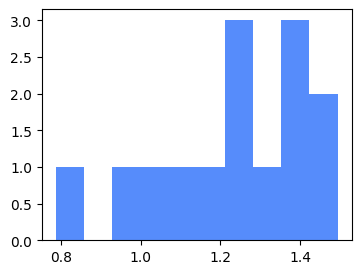

In [17]:
plt.figure(figsize = (4, 3))
plt.hist(pipeline.per_wb_parameters_["stride_duration_s"], bins = 10)
plt.show()